# Ejercicio 2 — Clasificación de prendas con Fashion MNIST

Se busca usar **TensorFlow** para descargar el dataset **Fashion MNIST**, construir una red neuronal para clasificar prendas de vestir.


## 1. Importación de librerías

- `tensorflow`: construcción y entrenamiento de la red.
- `numpy`: operaciones numéricas.
- `matplotlib.pyplot`: visualización de imágenes y resultados.

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


## 2. Carga del dataset

`tf.keras.datasets.fashion_mnist.load_data()` descarga Fashion MNIST y devuelve dos conjuntos:

- entrenamiento;
- prueba.

Cada imagen tiene tamaño de 28 × 28 píxeles y pertenece a una de 10 clases.

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28)
y_train: (60000,)
X_test : (10000, 28, 28)
y_test : (10000,)


## 3. Nombres de las clases

In [3]:
class_names = [
    "Camiseta/Top",
    "Pantalón",
    "Suéter",
    "Vestido",
    "Abrigo",
    "Sandalia",
    "Camisa",
    "Tenis",
    "Bolso",
    "Botín"
]

for i, nombre in enumerate(class_names):
    print(i, "->", nombre)

0 -> Camiseta/Top
1 -> Pantalón
2 -> Suéter
3 -> Vestido
4 -> Abrigo
5 -> Sandalia
6 -> Camisa
7 -> Tenis
8 -> Bolso
9 -> Botín


## 4. Visualización de ejemplos

Se muestran algunas imágenes del conjunto de entrenamiento junto con su rótulo.

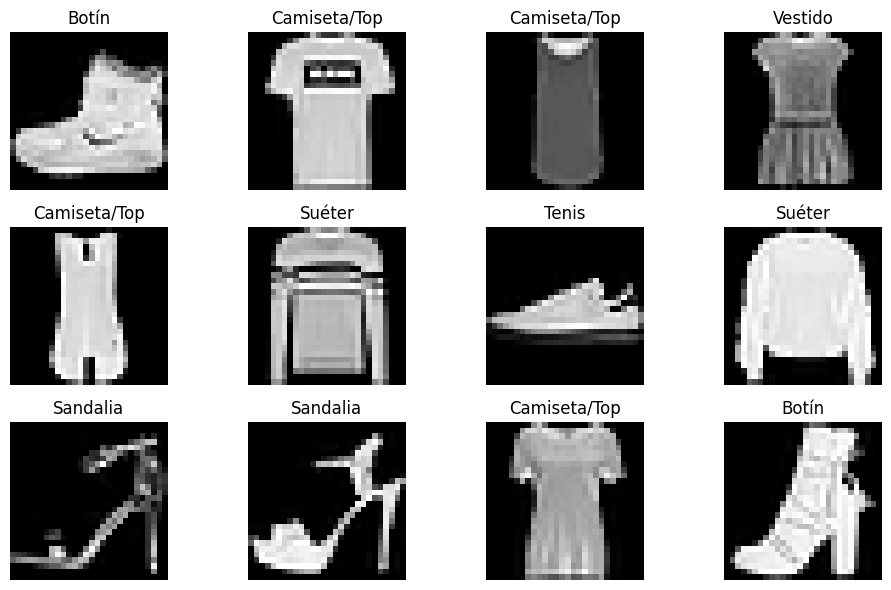

In [4]:
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Normalización

Los píxeles originales tienen valores entre 0 y 255. Se normalizan al intervalo [0,1]:

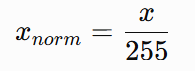

Esto facilita el entrenamiento de la red.

In [17]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Mínimo:", X_train.min())
print("Máximo:", X_train.max())

Mínimo: 0.0
Máximo: 0.003921569


## 6. Construcción de la red

Se utiliza `tf.keras.Sequential`, que permite agregar las capas en orden.

Arquitectura:

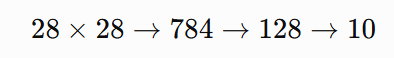

- `Input(shape=(28,28))`: define el tamaño de entrada.
- `Flatten()`: convierte la imagen 28 × 28 en un vector de 784 valores.
- `Dense(128, activation="relu")`: capa oculta con 128 neuronas y activación ReLU.
- `Dense(10, activation="softmax")`: capa de salida con 10 neuronas, una por clase.

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Compilación

`model.compile()` configura el aprendizaje:

- `optimizer="adam"`: algoritmo que actualiza los pesos.
- `loss="sparse_categorical_crossentropy"`: función de pérdida para clasificación multiclase con etiquetas enteras.
- `metrics=["accuracy"]`: calcula el porcentaje de aciertos.

In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 8. Entrenamiento

`model.fit()` entrena la red.

- `epochs=10`: diez recorridos completos del conjunto de entrenamiento.
- `batch_size=32`: se procesan 32 imágenes por actualización.
- `validation_split=0.2`: 20 % del conjunto de entrenamiento se reserva para validación.

Durante este proceso TensorFlow realiza internamente la propagación hacia adelante, el cálculo de la pérdida, el backpropagation y la actualización de pesos.

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8187 - loss: 0.5207 - val_accuracy: 0.8379 - val_loss: 0.4565
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8599 - loss: 0.3897 - val_accuracy: 0.8675 - val_loss: 0.3721
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8735 - loss: 0.3477 - val_accuracy: 0.8540 - val_loss: 0.4213
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8819 - loss: 0.3233 - val_accuracy: 0.8714 - val_loss: 0.3646
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8908 - loss: 0.3003 - val_accuracy: 0.8805 - val_loss: 0.3344
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8935 - loss: 0.2853 - val_accuracy: 0.8840 - val_loss: 0.3273
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8997 - loss: 0.2714 - val_accuracy: 0.8820 - val_loss: 0.3296
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9038 - loss: 0.2606 -

## 9. Evolución de la exactitud



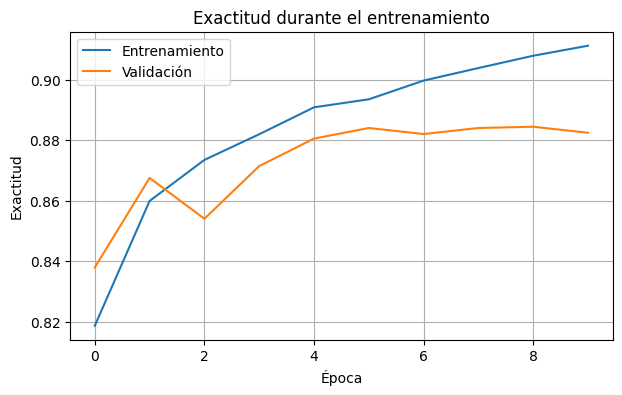

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Exactitud")
plt.title("Exactitud durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

## 10. Evolución de la función de pérdida

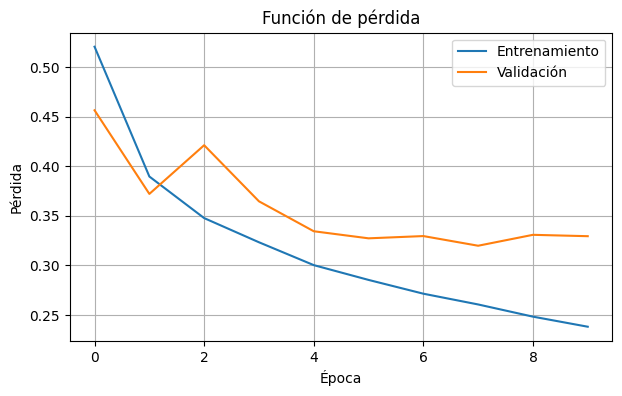

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Función de pérdida")
plt.legend()
plt.grid(True)
plt.show()

## 11. Evaluación sobre el conjunto de prueba

`model.evaluate()` mide el desempeño final con imágenes que no se usaron para ajustar los pesos.

In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Pérdida en prueba: {test_loss:.4f}")
print(f"Accuracy en prueba: {test_accuracy*100:.2f}%")

Pérdida en prueba: 0.3551
Accuracy en prueba: 87.23%


## 12. Predicciones

`model.predict()` entrega 10 probabilidades por imagen.


In [12]:
probabilidades = model.predict(X_test, verbose=0)
predicciones = np.argmax(probabilidades, axis=1)

print("Clase real       :", class_names[y_test[0]])
print("Clase predicha   :", class_names[predicciones[0]])
print("Probabilidad máx.:", probabilidades[0].max())

Clase real       : Botín
Clase predicha   : Botín
Probabilidad máx.: 0.99629635


## 13. Visualización de predicciones

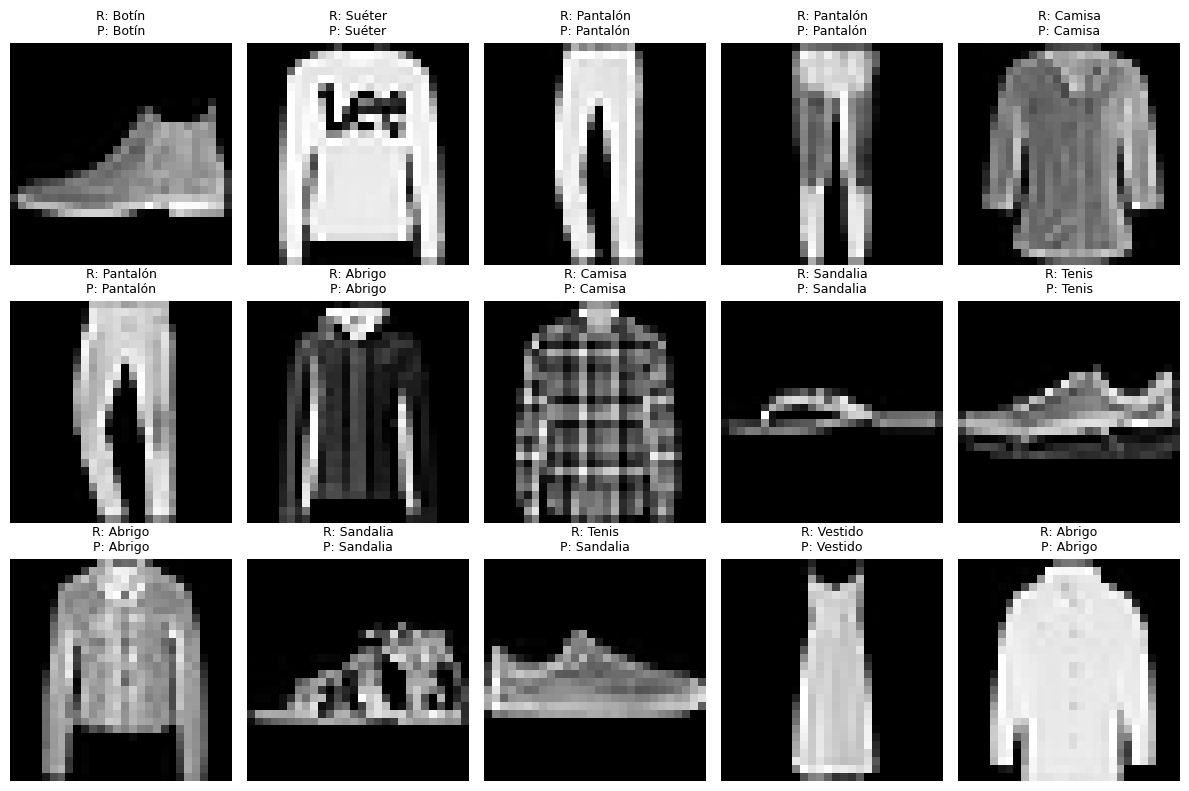

In [13]:
plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")

    real = class_names[y_test[i]]
    pred = class_names[predicciones[i]]

    plt.title(f"R: {real}\nP: {pred}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 14. Matriz de confusión

Las filas corresponden a las clases reales y las columnas a las clases predichas. Permite identificar qué prendas tienden a confundirse entre sí.

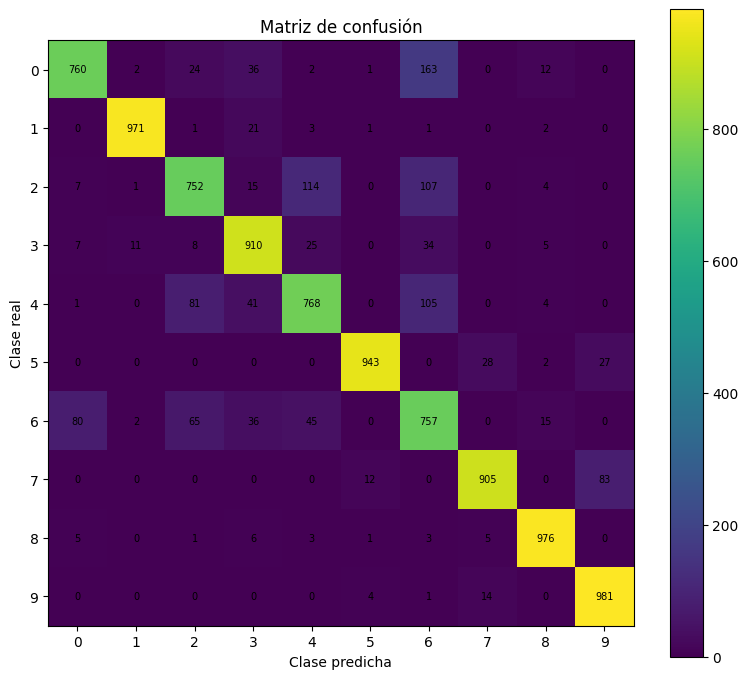

In [14]:
matriz_confusion = tf.math.confusion_matrix(
    y_test,
    predicciones,
    num_classes=10
).numpy()

plt.figure(figsize=(8, 7))
plt.imshow(matriz_confusion)
plt.title("Matriz de confusión")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.xticks(range(10), range(10))
plt.yticks(range(10), range(10))
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, matriz_confusion[i, j],
                 ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

## 15. Resumen de resultados

In [20]:
train_acc = history.history["accuracy"][-1]
val_acc = history.history["val_accuracy"][-1]

errores = np.where(predicciones != y_test)[0]

print("----- RESULTADOS FINALES -----")
print(f"Exactitud final de entrenamiento: {train_acc*100:.2f}%")
print(f"Exactitud final de validación   : {val_acc*100:.2f}%")
print(f"Exactitud de prueba       : {test_accuracy*100:.2f}%")
print(f"Errores en prueba        : {len(errores)} de {len(y_test)} imágenes")

----- RESULTADOS FINALES -----
Exactitud final de entrenamiento: 91.12%
Exactitud final de validación   : 88.24%
Exactitud de prueba       : 87.23%
Errores en prueba        : 1277 de 10000 imágenes


# Conclusiones

1. La capa `Flatten` convirtió cada imagen en un vector de características, mientras que la capa oculta con ReLU permitió aprender relaciones no lineales.
2. TensorFlow realizó de manera automática la propagación, el cálculo de la pérdida, el backpropagation y la actualización de los pesos.
3. La matriz de confusión permite identificar qué prendas son más difíciles de distinguir.
